<a href="https://colab.research.google.com/github/arjun-1238/Machine-Learning-Models/blob/main/Model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

arjuna98_bank_dataset_path = kagglehub.dataset_download('arjuna98/bank-dataset')

print('Data source import complete.')


In [ ]:
import pandas as pd
df=pd.read_csv("/kaggle/input/datasets/arjuna98/bank-dataset/bank-additional-full.csv",sep=";")
display(df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score,classification_report,precision_score,f1_score,recall_score,confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB


In [ ]:
df.drop_duplicates()
df.shape

(41188, 21)

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
categorical=df.select_dtypes(include="object").columns
numerical=df.select_dtypes(include=["int64","float64"]).columns

In [ ]:
df.columns=df.columns.str.replace(".","_").str.lower()

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [ ]:
import numpy as np
cat_col=['job','marital','education','default','housing','loan']
for i in cat_col:
    df[i]=df[i].replace("unknown",np.nan)



In [ ]:
num_cols=['age','duration','campaign','pdays','previous']
df[num_cols]=df[num_cols].astype(int)

In [ ]:
df['y']=df['y'].map({'no':0,'yes':1})

In [ ]:
df.shape

(41188, 21)

In [ ]:
df.drop_duplicates(inplace=True)
df.shape

(41176, 21)

In [ ]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['y'])
y=df["y"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)



In [ ]:
categorical=x_train.select_dtypes(include="object").columns
numerical=x_train.select_dtypes(include=["int64","float64"]).columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler

num_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",RobustScaler())
    ]
)

cat_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder())
    ]
)

preprocessor=ColumnTransformer(transformers=[
    ("num_pipeline",num_pipeline,numerical),
    ("cat_pipeline",cat_pipeline,categorical)
])

In [ ]:
x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler,SMOTE


x_under,y_under=RandomUnderSampler(random_state=42).fit_resample(x_train_processed,y_train)

x_over,y_over=RandomOverSampler(random_state=42).fit_resample(x_train_processed,y_train)

x_smote,y_smote=SMOTE(random_state=42).fit_resample(x_train_processed,y_train)

In [ ]:
models={
    "Logistic Regression": LogisticRegression(C=0.1,penalty="elasticnet",solver="saga",l1_ratio=0.5,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,criterion="entropy",splitter="best"),
    "Random Forest" :RandomForestClassifier(n_estimators=100,random_state=42,criterion="entropy",max_depth=8),
    "KNN":KNeighborsClassifier(n_neighbors=5,weights="distance",algorithm="auto",n_jobs=-1),
    "Naive Bayes":GaussianNB(),
    "SVC":SVC(C=1.0,kernel="rbf",gamma="scale"),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
}

for model_name, model in models.items():
    print(f"Training {model_name}\n")

    model.fit(x_under,y_under)

    y_pred=model.predict(x_test_processed)

    report=classification_report(y_test, y_pred)
    print(report)

    matrix=confusion_matrix(y_test,y_pred)
    print(matrix,"\n")

Training Logistic Regression



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.84      0.90      7265
           1       0.41      0.86      0.56       971

    accuracy                           0.84      8236
   macro avg       0.70      0.85      0.73      8236
weighted avg       0.91      0.84      0.86      8236

[[6089 1176]
 [ 138  833]] 

Training Decision Tree

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      7265
           1       0.40      0.93      0.56       971

    accuracy                           0.83      8236
   macro avg       0.69      0.87      0.73      8236
weighted avg       0.92      0.83      0.85      8236

[[5908 1357]
 [  64  907]] 

Training Random Forest

              precision    recall  f1-score   support

           0       0.99      0.80      0.89      7265
           1       0.39      0.95      0.55       971

    accuracy                           0.82      8236
   macro avg       0.6

In [ ]:
models={
    "Logistic Regression": LogisticRegression(C=0.1,penalty="elasticnet",solver="saga",l1_ratio=0.5,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,criterion="entropy",splitter="best"),
    "Random Forest" :RandomForestClassifier(n_estimators=100,random_state=42,criterion="entropy",max_depth=8),
    "KNN":KNeighborsClassifier(n_neighbors=5,weights="distance",algorithm="auto",n_jobs=-1),
    "Naive Bayes":GaussianNB(),
    "SVC":SVC(C=1.0,kernel="rbf",gamma="scale"),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
}

for model_name, model in models.items():
    print(f"Training {model_name}\n")

    model.fit(x_over,y_over)

    y_pred=model.predict(x_test_processed)

    report=classification_report(y_test,y_pred)
    print(report)

    matrix=confusion_matrix(y_test,y_pred)
    print(matrix,"\n")

Training Logistic Regression



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

           0       0.98      0.85      0.91      7265
           1       0.44      0.87      0.59       971

    accuracy                           0.85      8236
   macro avg       0.71      0.86      0.75      8236
weighted avg       0.92      0.85      0.87      8236

[[6196 1069]
 [ 127  844]] 

Training Decision Tree

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      7265
           1       0.41      0.91      0.57       971

    accuracy                           0.84      8236
   macro avg       0.70      0.87      0.74      8236
weighted avg       0.92      0.84      0.86      8236

[[6014 1251]
 [  85  886]] 

Training Random Forest

              precision    recall  f1-score   support

           0       0.99      0.83      0.90      7265
           1       0.42      0.93      0.58       971

    accuracy                           0.84      8236
   macro avg       0.7

In [ ]:
models={
    "Logistic Regression": LogisticRegression(C=0.1,penalty="elasticnet",solver="saga",l1_ratio=0.5,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,criterion="entropy",splitter="best"),
    "Random Forest" :RandomForestClassifier(n_estimators=100,random_state=42,criterion="entropy",max_depth=8),
    "KNN":KNeighborsClassifier(n_neighbors=5,weights="distance",algorithm="auto",n_jobs=-1),
    "Naive Bayes":GaussianNB(),
    "SVC":SVC(C=1.0,kernel="rbf",gamma="scale"),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
}

for model_name, model in models.items():
    print(f"Training {model_name}\n")

    model.fit(x_smote,y_smote)

    y_pred=model.predict(x_test_processed)

    report=classification_report(y_test, y_pred)
    print(report)

    matrix=confusion_matrix(y_test,y_pred)
    print(matrix,"\n")

In [ ]:
models={
    "Logistic Regression": LogisticRegression(C=0.1,penalty="elasticnet",solver="saga",l1_ratio=0.5,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,criterion="entropy",splitter="best"),
    "Random Forest" :RandomForestClassifier(n_estimators=100,random_state=42,criterion="entropy",max_depth=8),
    "KNN":KNeighborsClassifier(n_neighbors=5,weights="distance",algorithm="auto",n_jobs=-1),
    "Naive Bayes":GaussianNB(),
    "SVC":SVC(C=1.0,kernel="rbf",gamma="scale"),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
}

undersampling_result={}

for model_name, model in models.items():
    print(f"Training {model_name}\n")

    model.fit(x_under,y_under)

    y_pred=model.predict(x_test_processed)

    acc=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    undersampling_result[model_name]=[acc,precision,recall,f1]

    matrix=confusion_matrix(y_test,y_pred)
    print(matrix,"\n")

Training Logistic Regression



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[[6089 1176]
 [ 138  833]] 

Training Decision Tree

[[5908 1357]
 [  64  907]] 

Training Random Forest

[[5828 1437]
 [  52  919]] 

Training KNN

[[6008 1257]
 [ 121  850]] 

Training Naive Bayes

[[6371  894]
 [ 421  550]] 

Training SVC

[[7160  105]
 [ 772  199]] 

Training Gradient Boosting

[[6038 1227]
 [  71  900]] 



In [ ]:
models={
    "Logistic Regression": LogisticRegression(C=0.1,penalty="elasticnet",solver="saga",l1_ratio=0.5,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,criterion="entropy",splitter="best"),
    "Random Forest" :RandomForestClassifier(n_estimators=100,random_state=42,criterion="entropy",max_depth=8),
    "KNN":KNeighborsClassifier(n_neighbors=5,weights="distance",algorithm="auto",n_jobs=-1),
    "Naive Bayes":GaussianNB(),
    "SVC":SVC(C=1.0,kernel="rbf",gamma="scale"),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
}
oversampling_result={}

for model_name,model in models.items():
    print(f"Training {model_name}\n")

    model.fit(x_over,y_over)
    y_pred=model.predict(x_test_processed)

    acc=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    oversampling_result[model_name]=[acc,precision,recall,f1]

    matrix=confusion_matrix(y_test,y_pred)
    print(matrix,"\n")

Training Logistic Regression



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[[6196 1069]
 [ 127  844]] 

Training Decision Tree

[[6014 1251]
 [  85  886]] 

Training Random Forest

[[6006 1259]
 [  69  902]] 

Training KNN

[[6388  877]
 [ 265  706]] 

Training Naive Bayes

[[6419  846]
 [ 437  534]] 

Training SVC

[[6761  504]
 [ 375  596]] 

Training Gradient Boosting

[[6128 1137]
 [  81  890]] 



In [ ]:
models={
    "Logistic Regression": LogisticRegression(C=0.1,penalty="elasticnet",solver="saga",l1_ratio=0.5,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,criterion="entropy",splitter="best"),
    "Random Forest" :RandomForestClassifier(n_estimators=100,random_state=42,criterion="entropy",max_depth=8),
    "KNN":KNeighborsClassifier(n_neighbors=5,weights="distance",algorithm="auto",n_jobs=-1),
    "Naive Bayes":GaussianNB(),
    "SVC":SVC(C=1.0,kernel="rbf",gamma="scale"),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
}

smote_result={}

for model_name, model in models.items():
    print(f"Training {model_name}\n")

    model.fit(x_smote,y_smote)

    y_pred=model.predict(x_test_processed)

    acc=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    smote_result[model_name]=[acc,precision,recall,f1]

    matrix=confusion_matrix(y_test,y_pred)
    print(matrix,"\n")

Training Logistic Regression



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[[6232 1033]
 [ 129  842]] 

Training Decision Tree

[[6143 1122]
 [ 124  847]] 

Training Random Forest

[[6251 1014]
 [ 131  840]] 

Training KNN

[[6277  988]
 [ 211  760]] 

Training Naive Bayes

[[6337  928]
 [ 409  562]] 

Training SVC

[[6739  526]
 [ 365  606]] 

Training Gradient Boosting

[[6513  752]
 [ 177  794]] 



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.858912,0.449067,0.867147,0.591708
1,Decision Tree,0.848713,0.430168,0.872297,0.576190
2,Random Forest,0.860976,0.453074,0.865088,0.594690
3,KNN,0.854420,0.434783,0.782698,0.559029
4,Naive Bayes,0.837664,0.377181,0.578785,0.456725
5,SVC,0.891816,0.535336,0.624099,0.576320
6,Gradient Boosting,0.887203,0.513583,0.817714,0.630910


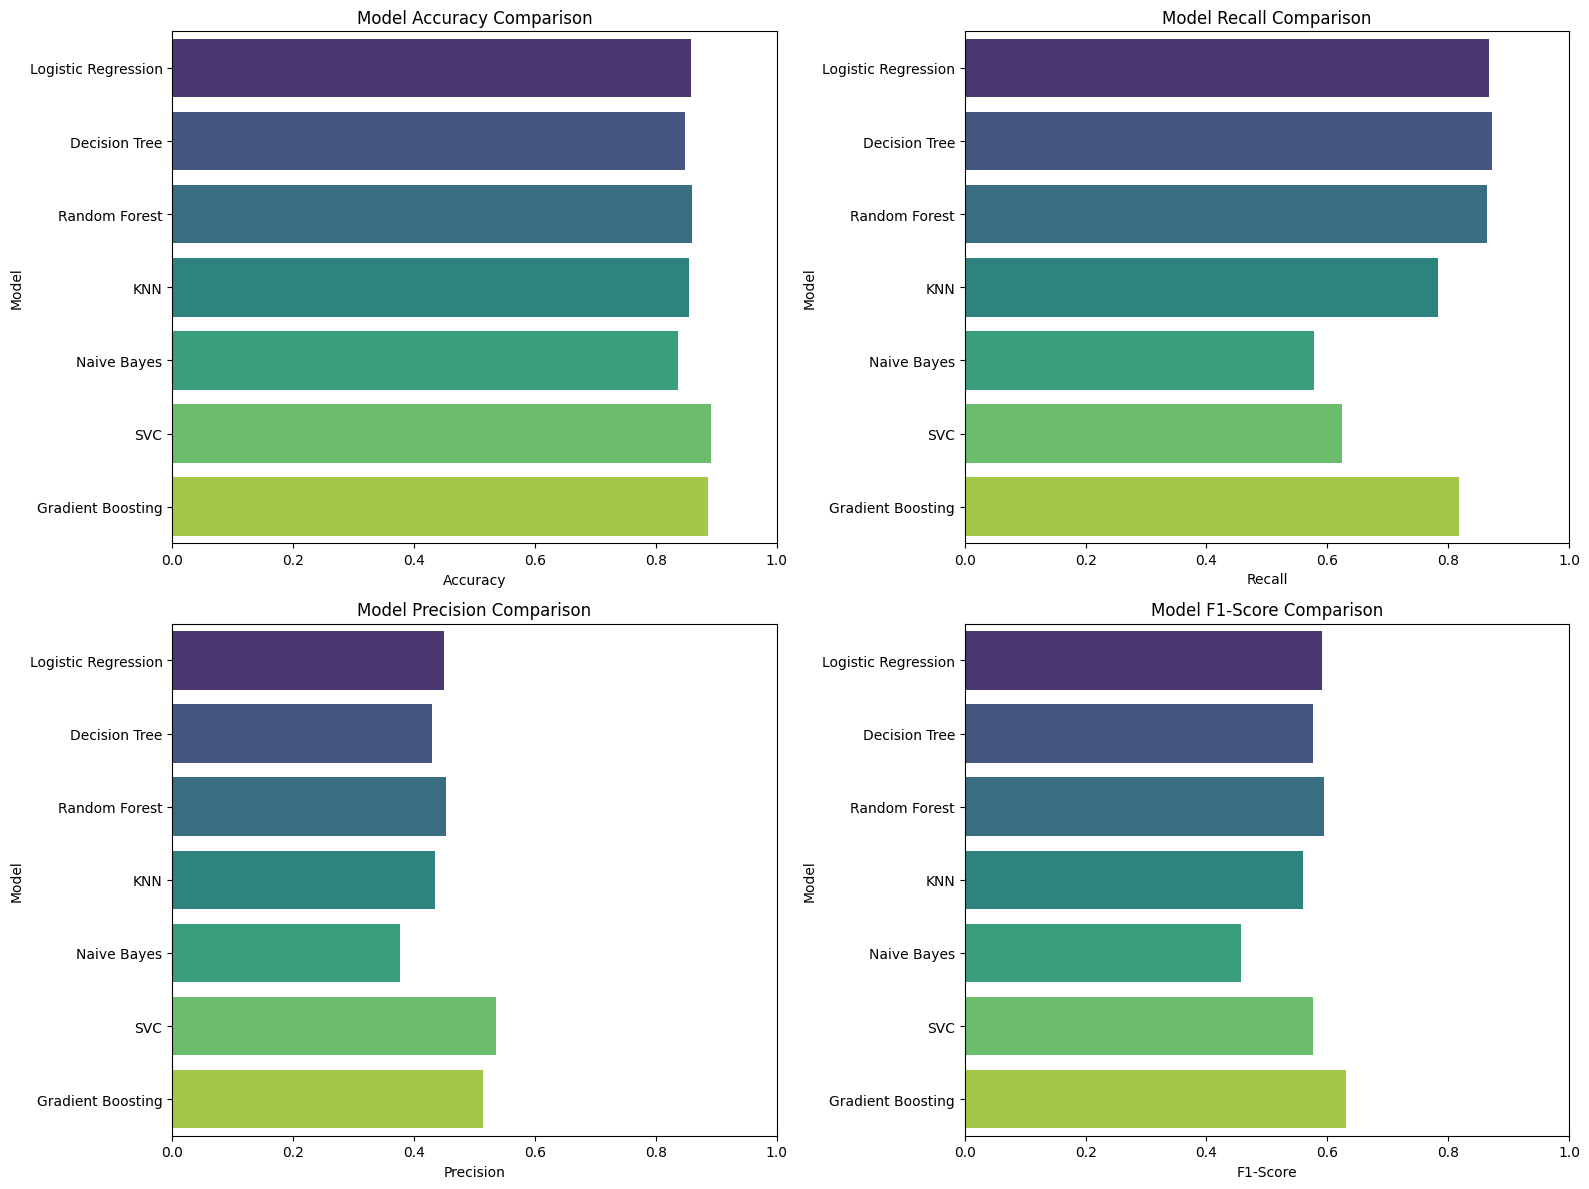

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

smote=pd.DataFrame.from_dict(smote_result,orient='index',
      columns=['Accuracy','Precision',"Recall",'F1-Score']).reset_index()

smote.rename(columns={'index':'Model'},inplace=True)
display(smote)

plt.figure(figsize=(16,12))

plt.subplot(2,2,1)
sns.barplot(data=smote,x='Accuracy',y='Model',palette='viridis',hue="Model")
plt.title('Model Accuracy Comparison')
plt.xlim(0,1)

plt.subplot(2,2,2)
sns.barplot(data=smote,x='Recall',y='Model',palette='viridis',hue="Model")
plt.title('Model Recall Comparison')
plt.xlim(0,1)

plt.subplot(2,2,3)
sns.barplot(data=smote,x='Precision',y='Model',palette='viridis',hue="Model")
plt.title('Model Precision Comparison')
plt.xlim(0,1)

plt.subplot(2,2,4)
sns.barplot(data=smote,x='F1-Score',y='Model',palette='viridis',hue="Model")
plt.title("Model F1-Score Comparison")
plt.xlim(0,1)
plt.tight_layout()
plt.show()

,Feature,Importance
1,num_pipeline__duration,0.353066
8,num_pipeline__euribor3m,0.115889
9,num_pipeline__nr_employed,0.091820
5,num_pipeline__emp_var_rate,0.068968
7,num_pipeline__cons_conf_idx,0.046125
3,num_pipeline__pdays,0.029911
2,num_pipeline__campaign,0.029904
56,cat_pipeline__poutcome_success,0.027485
6,num_pipeline__cons_price_idx,0.027344
45,cat_pipeline__month_may,0.021274


/tmp/ipykernel_58/427091290.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature',palette='viridis')


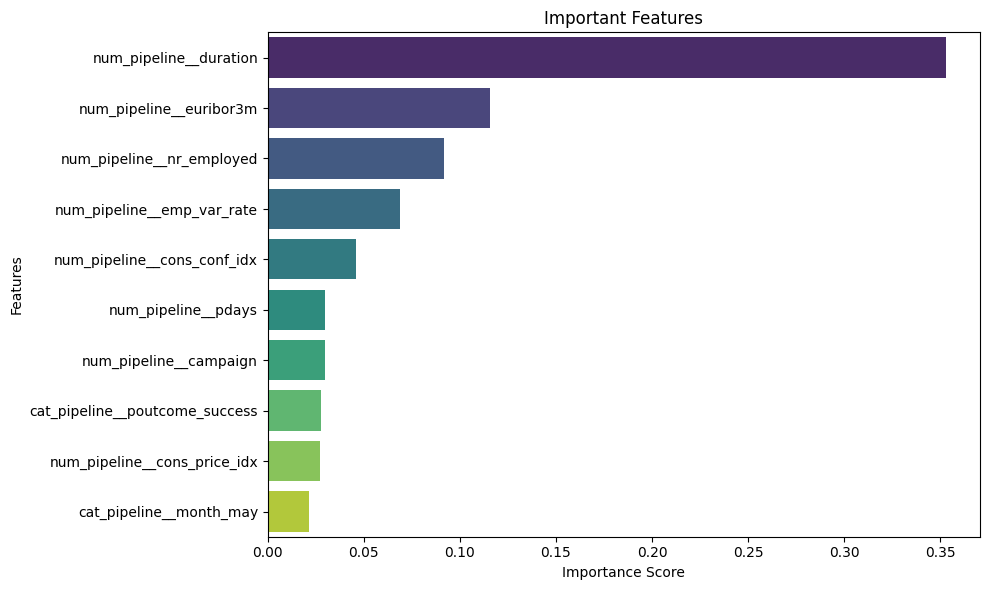

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model = models["Random Forest"]

feature_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False)
display(importance_df.head(10))
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10),x='Importance',y='Feature',palette='viridis')
plt.title('Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
df.columns

In [ ]:
from sklearn.model_selection import train_test_split
x=df[["duration","euribor3m","nr_employed","emp_var_rate","cons_conf_idx","pdays","campaign","poutcome",'cons_price_idx',"month"]]
y=df["y"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

categorical=x_train.select_dtypes(include="object").columns
numerical=x_train.select_dtypes(include=["int64","float64"]).columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler

num_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",RobustScaler())
    ]
)

cat_pipeline=Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder())
    ]
)

preprocessor=ColumnTransformer(transformers=[
    ("num_pipeline",num_pipeline,numerical),
    ("cat_pipeline",cat_pipeline,categorical)
])

x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)



In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler,SMOTE


x_under,y_under=RandomUnderSampler(random_state=42).fit_resample(x_train_processed,y_train)

x_over,y_over=RandomOverSampler(random_state=42).fit_resample(x_train_processed,y_train)

x_smote,y_smote=SMOTE(random_state=42).fit_resample(x_train_processed,y_train)

In [ ]:
models={
    "Logistic Regression": LogisticRegression(C=0.1,penalty="elasticnet",solver="saga",l1_ratio=0.5,max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,criterion="entropy",splitter="best"),
    "Random Forest" :RandomForestClassifier(n_estimators=100,random_state=42,criterion="entropy",max_depth=8),
    "KNN":KNeighborsClassifier(n_neighbors=5,weights="distance",algorithm="auto",n_jobs=-1),
    "Naive Bayes":GaussianNB(),
    "SVC":SVC(C=1.0,kernel="rbf",gamma="scale"),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
}

for model_name, model in models.items():
    print(f"Training {model_name}\n")

    model.fit(x_under,y_under)

    y_pred=model.predict(x_test_processed)

    report=classification_report(y_test, y_pred)
    print(report)

    matrix=confusion_matrix(y_test,y_pred)
    print(matrix,"\n")

In [ ]:
models={
    "Logistic Regression": LogisticRegression(C=0.1,penalty="elasticnet",solver="saga",l1_ratio=0.5,max_iter=3000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,criterion="entropy",splitter="best"),
    "Random Forest" :RandomForestClassifier(n_estimators=100,random_state=42,criterion="entropy",max_depth=8),
    "KNN":KNeighborsClassifier(n_neighbors=5,weights="distance",algorithm="auto",n_jobs=-1),
    "Naive Bayes":GaussianNB(),
    "SVC":SVC(C=1.0,kernel="rbf",gamma="scale"),
    "Gradient Boosting":GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
}

for model_name, model in models.items():
    print(f"Training {model_name}\n")

    model.fit(x_smote,y_smote)

    y_pred=model.predict(x_test_processed)

    report=classification_report(y_test, y_pred)
    print(report)

    matrix=confusion_matrix(y_test,y_pred)
    print(matrix,"\n")